In [1]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
import lime
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def analizar_tarea(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # IMPORTANTO: se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Verificamos el prefijo del número para no confundir 1 con 11, 21...
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return None

    print(f"Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Crear un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    print(f"Tarea {num_tarea} extraída: {len(cols_tarea)} variables + 'class'.")
    return df_tarea

    # --- EJECUCIÓN ---
df_1 = analizar_tarea(df, 1)
df_2 = analizar_tarea(df, 2)
df_3 = analizar_tarea(df, 3)
df_4 = analizar_tarea(df, 4)
df_5 = analizar_tarea(df, 5)
df_6 = analizar_tarea(df, 6)
df_7 = analizar_tarea(df, 7)
df_8 = analizar_tarea(df, 8)
df_9 = analizar_tarea(df, 9)
df_10 = analizar_tarea(df, 10)
df_11 = analizar_tarea(df, 11)
df_12 = analizar_tarea(df, 12)
df_13 = analizar_tarea(df, 13)
df_14 = analizar_tarea(df, 14)
df_15 = analizar_tarea(df, 15)
df_16 = analizar_tarea(df, 16)
df_17 = analizar_tarea(df, 17)
df_18 = analizar_tarea(df, 18)
df_19 = analizar_tarea(df, 19)
df_20 = analizar_tarea(df, 20)
df_21 = analizar_tarea(df, 21)
df_22 = analizar_tarea(df, 22)
df_23 = analizar_tarea(df, 23)
df_24 = analizar_tarea(df, 24)
df_25 = analizar_tarea(df, 25)

Analizando Tarea 1 (18 variables)
Tarea 1 extraída: 18 variables + 'class'.
Analizando Tarea 2 (18 variables)
Tarea 2 extraída: 18 variables + 'class'.
Analizando Tarea 3 (18 variables)
Tarea 3 extraída: 18 variables + 'class'.
Analizando Tarea 4 (18 variables)
Tarea 4 extraída: 18 variables + 'class'.
Analizando Tarea 5 (18 variables)
Tarea 5 extraída: 18 variables + 'class'.
Analizando Tarea 6 (18 variables)
Tarea 6 extraída: 18 variables + 'class'.
Analizando Tarea 7 (18 variables)
Tarea 7 extraída: 18 variables + 'class'.
Analizando Tarea 8 (18 variables)
Tarea 8 extraída: 18 variables + 'class'.
Analizando Tarea 9 (18 variables)
Tarea 9 extraída: 18 variables + 'class'.
Analizando Tarea 10 (18 variables)
Tarea 10 extraída: 18 variables + 'class'.
Analizando Tarea 11 (18 variables)
Tarea 11 extraída: 18 variables + 'class'.
Analizando Tarea 12 (18 variables)
Tarea 12 extraída: 18 variables + 'class'.
Analizando Tarea 13 (18 variables)
Tarea 13 extraída: 18 variables + 'class'.
Anal

In [110]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df_1.drop(['class'], axis = 1)

# Y contiene 'class'
Y = df_1['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [111]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

# ANÁLISIS DE ML 4

## DECISION TREE

In [5]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.50      0.41      0.45        17
           1       0.52      0.61      0.56        18

    accuracy                           0.51        35
   macro avg       0.51      0.51      0.51        35
weighted avg       0.51      0.51      0.51        35

--- MATRIZ DE CONFUSIÓN ---
[[ 7 10]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.41


In [20]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

param_grid_dt = {
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejor combinación: {'max_depth': np.int64(3), 'min_samples_leaf': np.int64(12), 'min_samples_split': np.int64(2)}
Mejor accuracy en CV: 0.734126984126984
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.50      0.59      0.54        17
           1       0.53      0.44      0.48        18

    accuracy                           0.51        35
   macro avg       0.52      0.52      0.51        35
weighted avg       0.52      0.51      0.51        35

--- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [10  8]]
Sensibilidad: 0.44
Especificidad: 0.59


**SHAP**

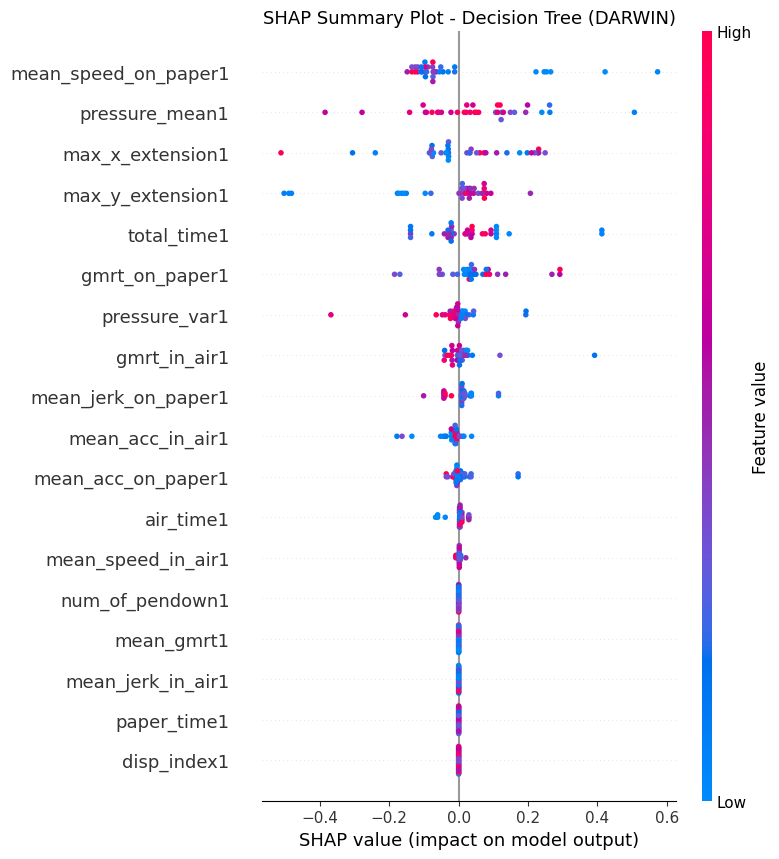

✔ Summary plot guardado.


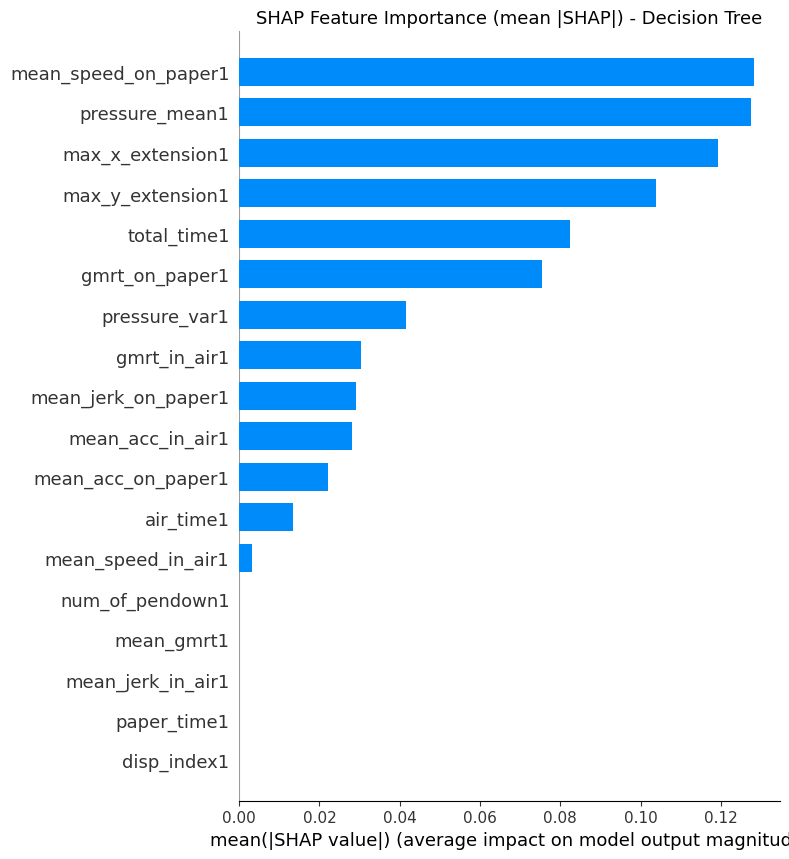

✔ Bar plot guardado.


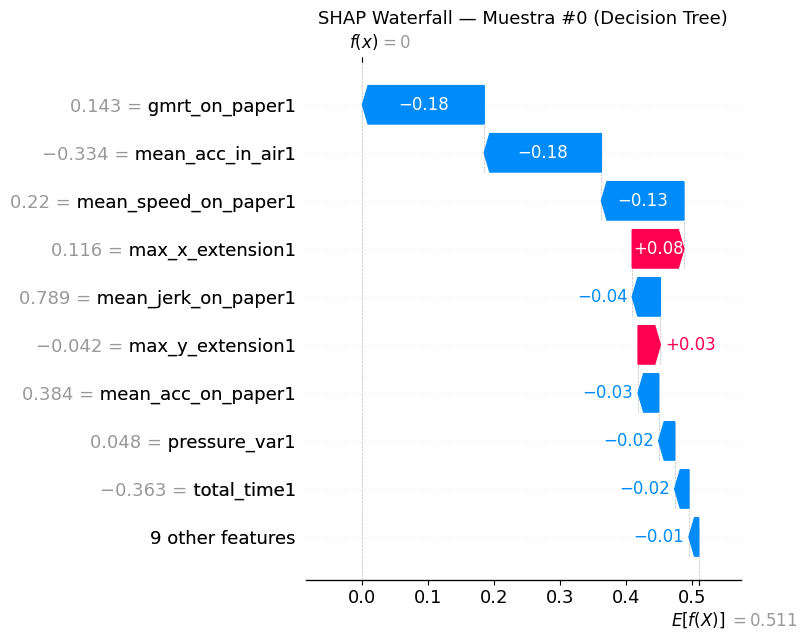

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

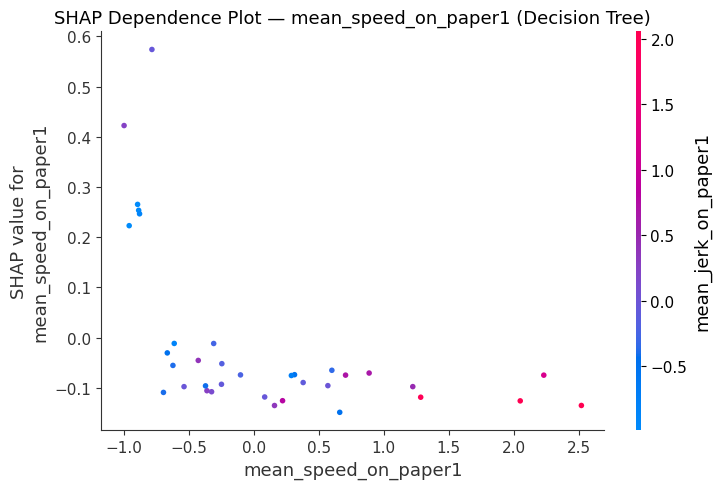

✔ Dependence plot guardado para: mean_speed_on_paper1

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===
             Feature  Mean |SHAP|
mean_speed_on_paper1     0.128322
      pressure_mean1     0.127424
    max_x_extension1     0.119276
    max_y_extension1     0.103748
         total_time1     0.082429
      gmrt_on_paper1     0.075421
       pressure_var1     0.041671
        gmrt_in_air1     0.030321
 mean_jerk_on_paper1     0.029177
    mean_acc_in_air1     0.028066


In [6]:
# ============================================================
# ANÁLISIS SHAP PARA DECISION TREE
# ============================================================

# Explainer
explainer_dt = shap.TreeExplainer(tree_model) # best_tree o tree_model
 
# SHAP values
shap_values_dt = explainer_dt.shap_values(X_test_scaled)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv = np.array(shap_values_dt)[:, :, 1]  # shape (35, 450)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Decision Tree (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Decision Tree", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 0

explanation_dt = shap.Explanation(
    values=sv[sample_idx],
    base_values=explainer_dt.expected_value[1],
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_dt, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)
top_feature_idx_dt = np.argmax(mean_abs_shap_dt)
top_feature_name_dt = X.columns[top_feature_idx_dt]

plt.figure()
shap.dependence_plot(
    top_feature_idx_dt,
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_dt} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_dt}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)

feature_importance_dt_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_dt
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===")
print(feature_importance_dt_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 0 ---
Clase real     : 0
Clase predicha : 0
Probabilidades : H=1.000 | P=0.000

Top features (peso LIME):
  -0.22 < mean_speed_on_paper1 <= 0.24           -0.1903
  max_x_extension1 > 0.03                        -0.1704
  air_time1 <= -0.32                             -0.1145
  mean_jerk_on_paper1 > 0.18                     -0.1028
  -0.37 < total_time1 <= -0.22                   -0.0898
  -0.20 < gmrt_on_paper1 <= 0.25                 -0.0721
  -0.21 < max_y_extension1 <= 0.43               +0.0606
  gmrt_in_air1 > 0.35                            -0.0425
  pressure_mean1 > 0.76                          -0.0250
  mean_acc_on_paper1 > 0.13                      -0.0196
  -0.42 < paper_time1 <= -0.22                   -0.0194
  -0.37 < mean_jerk_in_air1 <= 0.03              -0.0175
  -0.19 < num_of_pendown1 <= 0.47                -0.0139
  -0.59 < disp_index1 <= -0.12                   -0.0094
  -0.37 < mean_acc_in_air1 <= 0.01               +0.0073


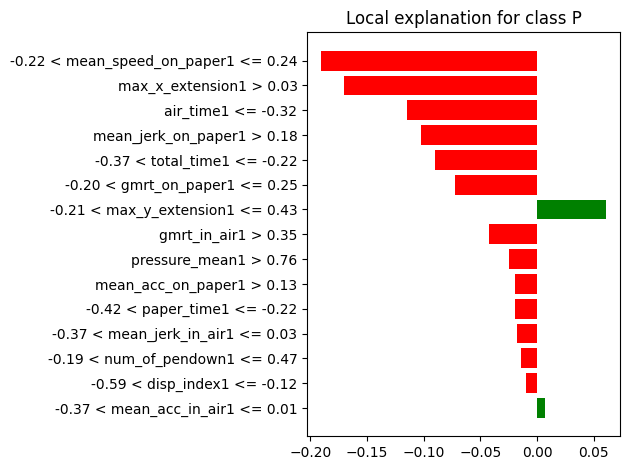


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. mean_speed_on_paper1                      0.26349
   2. pressure_mean1                            0.16016
   3. max_x_extension1                          0.09467
   4. max_y_extension1                          0.07515
   5. mean_jerk_on_paper1                       0.06999
   6. total_time1                               0.06515
   7. air_time1                                 0.05600
   8. gmrt_in_air1                              0.05069
   9. gmrt_on_paper1                            0.04806
  10. pressure_var1                             0.04176
  11. paper_time1                               0.03879
  12. mean_acc_in_air1                          0.03762
  13. disp_index1                               0.03726
  14. mean_jerk_in_air1                         0.03228
  15. mean_gmrt1                                0.03172
  16. mean_acc_on_paper1                        0.03056
  17. num_of_pendow

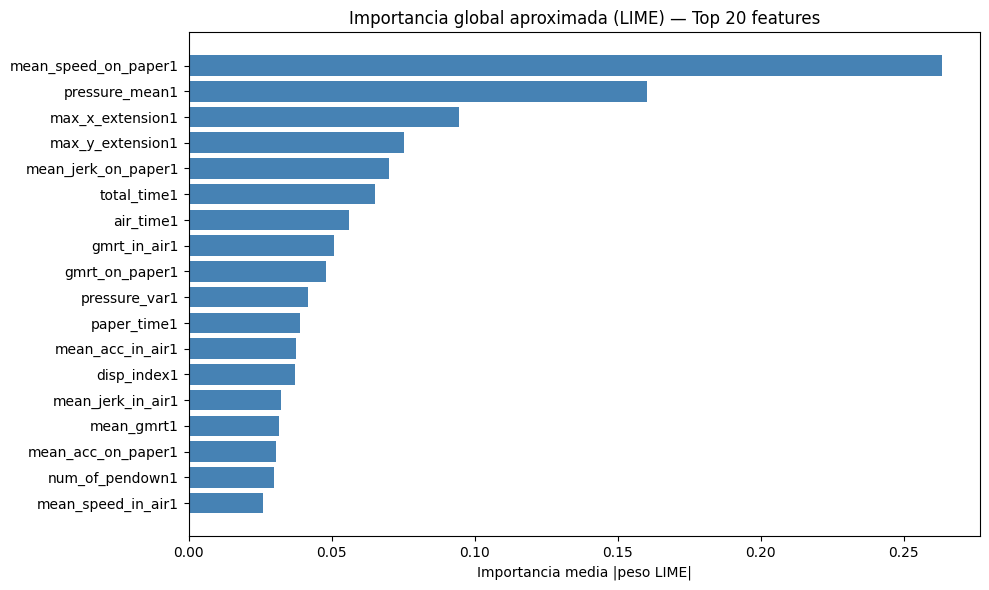

In [7]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 0
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = tree_model.predict_proba, # best_tree o tree_model
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_dt[INSTANCE_IDX]}") # Y_pred_opt Y_pred_dt
print(f"Probabilidades : H={tree_model.predict_proba([instance])[0][0]:.3f} | " # best
      f"P={tree_model.predict_proba([instance])[0][1]:.3f}")  # best
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = tree_model.predict_proba, # best
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## RANDOM FOREST

In [8]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.72      0.76      0.74        17
           1       0.76      0.72      0.74        18

    accuracy                           0.74        35
   macro avg       0.74      0.74      0.74        35
weighted avg       0.74      0.74      0.74        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.76


In [24]:
# Se define el Grid 
param_grid_rf = {
    'max_depth': np.arange(3, 11, 1),           # 3 a 10 (step 1)
    'n_estimators': np.arange(100, 350, 50),    # 100 a 300 
    'bootstrap': [True, False],                 # true y False
    'min_samples_split': [2],                   
    'min_samples_leaf': [1]
}                  

# Se configura el buscador
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Se entrena buscando la mejor combinación
grid_rf.fit(X_train_scaled, Y_train)

# Mejor modelo 
best_rf = grid_rf.best_estimator_
#print(f"Mejores parámetros: {grid_rf.best_params_}")

# Se realizan las predicciones
Y_pred_rf2 = best_rf.predict(X_test_scaled)

print("--- INFORME CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_rf2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf2))

# Sensibilidad y especificidad
tn_rf2, fp_rf2, fn_rf2, tp_rf2 = confusion_matrix(Y_test, Y_pred_rf2).ravel()

print(f"Sensibilidad: {tp_rf2 / (tp_rf2 + fn_rf2):.2f}")
print(f"Especificidad: {tn_rf2 / (tn_rf2 + fp_rf2):.2f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits


--- INFORME CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.60      0.50      0.55        18

    accuracy                           0.57        35
   macro avg       0.57      0.57      0.57        35
weighted avg       0.58      0.57      0.57        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 9  9]]
Sensibilidad: 0.50
Especificidad: 0.65


**SHAP**

Shape shap_values_rf: (35, 18, 2)
Shape sv_rf: (35, 18)


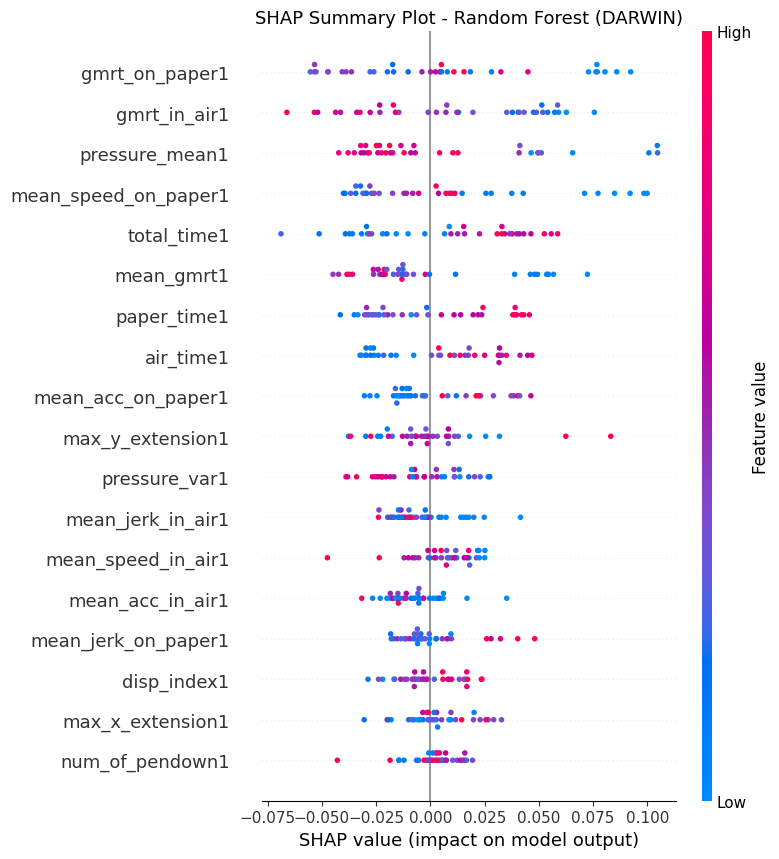

✔ Summary plot guardado.


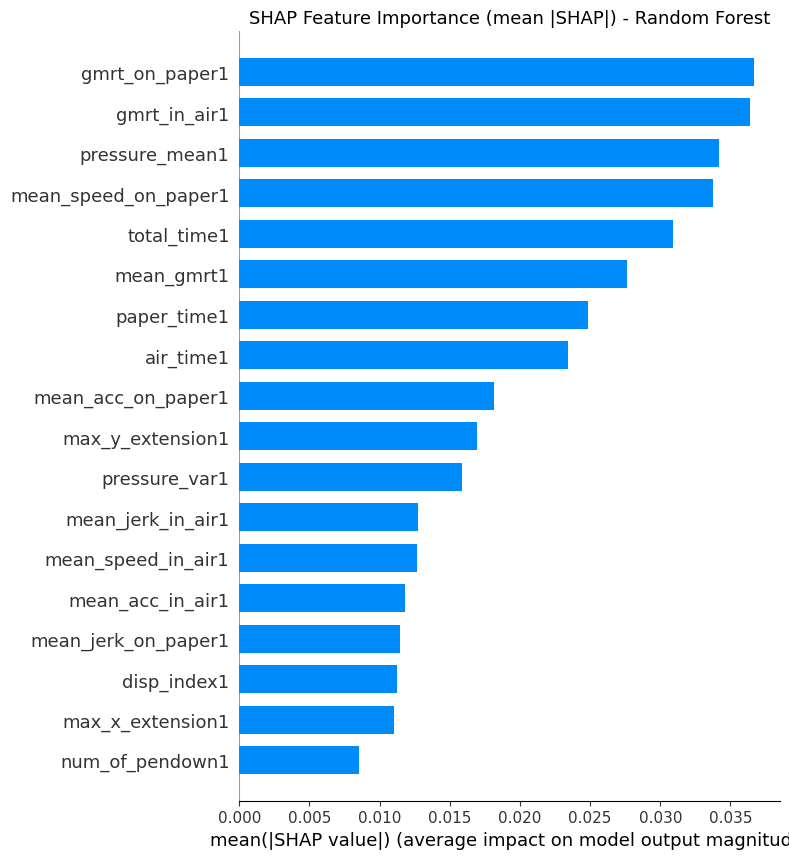

✔ Bar plot guardado.
expected_value_rf: [0.48964029 0.51035971]


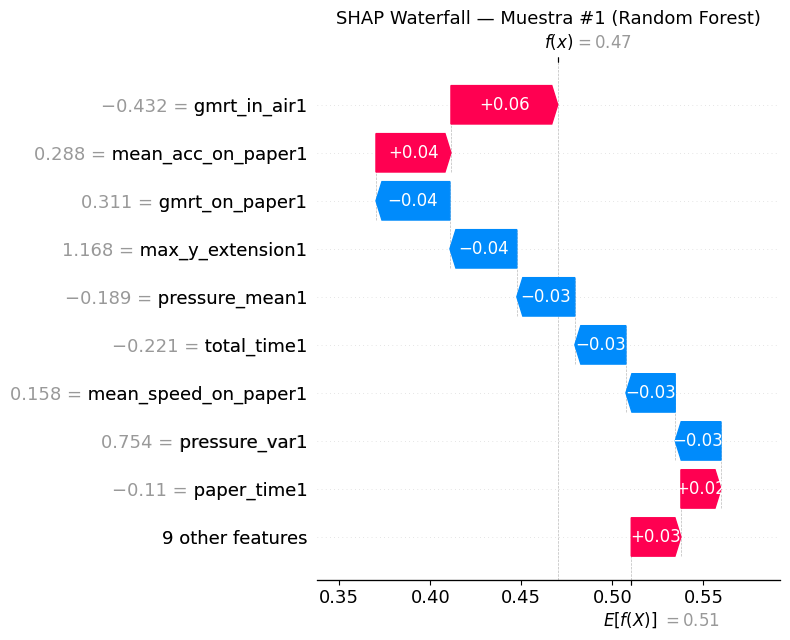

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

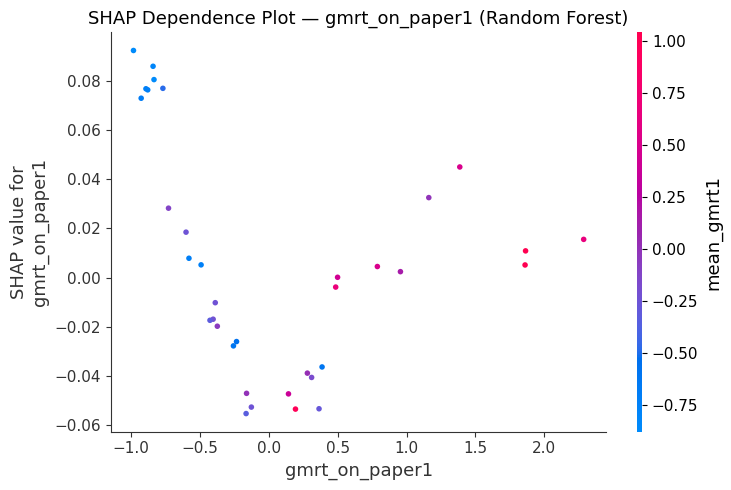

✔ Dependence plot guardado para: gmrt_on_paper1

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===
             Feature  Mean |SHAP|
      gmrt_on_paper1     0.036697
        gmrt_in_air1     0.036373
      pressure_mean1     0.034219
mean_speed_on_paper1     0.033767
         total_time1     0.030908
          mean_gmrt1     0.027618
         paper_time1     0.024854
           air_time1     0.023405
  mean_acc_on_paper1     0.018146
    max_y_extension1     0.016970


In [9]:
# ============================================================
# ANÁLISIS SHAP PARA RANDOM FOREST
# ============================================================

# Explainer
explainer_rf = shap.TreeExplainer(rf_model) # rf_model o best_rf

# SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

# Verificar estructura (por consistencia con tu entorno)
print("Shape shap_values_rf:", np.array(shap_values_rf).shape)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv_rf = np.array(shap_values_rf)[:, :, 1]  # shape (35, 450)
print("Shape sv_rf:", sv_rf.shape)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Random Forest (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 1

# Verificar expected_value
print("expected_value_rf:", explainer_rf.expected_value)

explanation_rf = shap.Explanation(
    values=sv_rf[sample_idx],
    base_values=explainer_rf.expected_value[1],  # si es escalar → quitar [1]
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_rf, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_rf = np.abs(sv_rf).mean(axis=0)
top_feature_idx_rf = np.argmax(mean_abs_shap_rf)
top_feature_name_rf = X.columns[top_feature_idx_rf]

plt.figure()
shap.dependence_plot(
    top_feature_idx_rf,
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_rf} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_rf}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_rf
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===")
print(feature_importance_rf_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 0 ---
Clase real     : 0
Clase predicha : 0
Probabilidades : H=0.660 | P=0.340
  gmrt_in_air1 > 0.35                            -0.0560
  -0.20 < gmrt_on_paper1 <= 0.25                 -0.0492
  -0.22 < mean_speed_on_paper1 <= 0.24           -0.0396
  -0.37 < total_time1 <= -0.22                   -0.0365
  mean_jerk_on_paper1 > 0.18                     +0.0327
  mean_gmrt1 > 0.30                              -0.0293
  -0.42 < paper_time1 <= -0.22                   -0.0288
  mean_acc_on_paper1 > 0.13                      +0.0273
  air_time1 <= -0.32                             -0.0225
  -0.37 < mean_jerk_in_air1 <= 0.03              -0.0197
  -0.19 < num_of_pendown1 <= 0.47                +0.0169
  pressure_mean1 > 0.76                          -0.0100
  -0.37 < mean_acc_in_air1 <= 0.01               -0.0092
  max_x_extension1 > 0.03                        +0.0092
  -0.21 < mean_speed_in_air1 <= 0.27             -0.0088


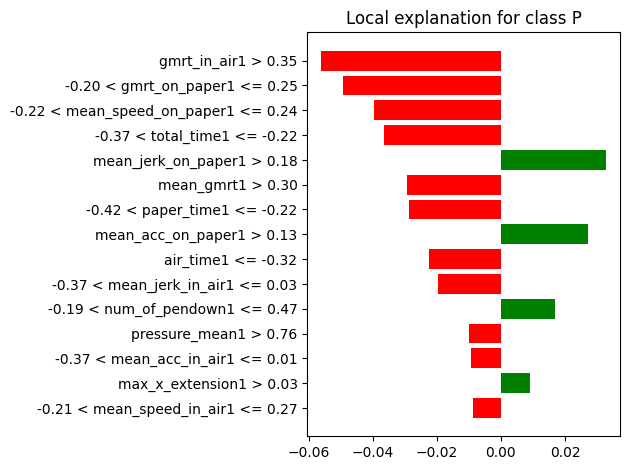


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. mean_speed_on_paper1                      0.04650
   2. gmrt_on_paper1                            0.04242
   3. gmrt_in_air1                              0.03594
   4. mean_gmrt1                                0.03552
   5. paper_time1                               0.03360
   6. pressure_mean1                            0.03321
   7. total_time1                               0.03082
   8. mean_acc_on_paper1                        0.02316
   9. air_time1                                 0.02312
  10. mean_jerk_on_paper1                       0.02259
  11. pressure_var1                             0.02072
  12. mean_speed_in_air1                        0.01797
  13. mean_jerk_in_air1                         0.01680
  14. num_of_pendown1                           0.01315
  15. mean_acc_in_air1                          0.01237
  16. max_y_extension1                          0.01160
  17. disp_index1  

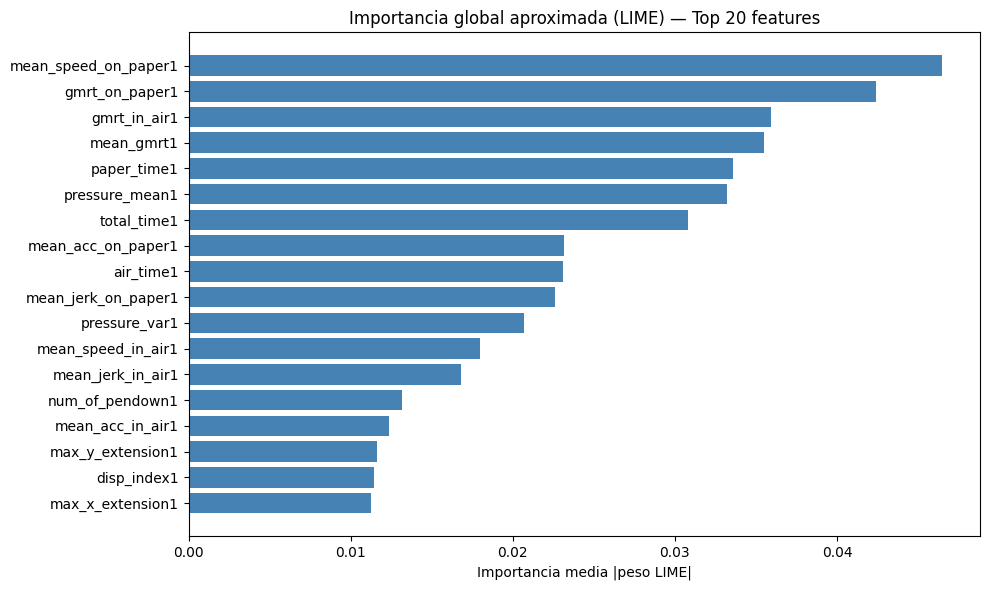

In [10]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 0
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = rf_model.predict_proba, # rf_model best_rf
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_rf[INSTANCE_IDX]}") # Y_pred_rf Y_pred_rf2
print(f"Probabilidades : H={rf_model.predict_proba([instance])[0][0]:.3f} | " # rf_model best_rf
      f"P={rf_model.predict_proba([instance])[0][1]:.3f}") # best
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = rf_model.predict_proba, # rf_model
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## XGBOOST

In [112]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

print(f"Sensibilidad: {tp_xgb / (tp_xgb + fn_xgb):.2f}")
print(f"Especificidad: {tn_xgb / (tn_xgb + fp_xgb):.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.56      0.50      0.53        18

    accuracy                           0.54        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.54      0.54      0.54        35

--- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 9  9]]
Sensibilidad: 0.50
Especificidad: 0.59


/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [19:51:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [137]:
# Modelo
modelo_xgb2 = xgb.XGBClassifier(
    n_estimators = 200, # nº árboles
    learning_rate = 0.05, # paso de aprendizaje
    max_depth = 4, # profundidad árboles
    gamma = 0.2, # reg para evitar ramas débiles
    subsample = 0.8, 
    colsample_bytree=0.8,
    scale_pos_weight=1.2,
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb2.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb2 = modelo_xgb2.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb2))

# TP; TN; FP; FN
tn_xgb2, fp_xgb2, fn_xgb2, tp_xgb2 = confusion_matrix(Y_test, Y_pred_xgb2).ravel()

print(f"Sensibilidad: {tp_xgb2 / (tp_xgb2 + fn_xgb2):.2f}")
print(f"Especificidad: {tn_xgb2 / (tn_xgb2 + fp_xgb2):.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [22:02:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**SHAP**

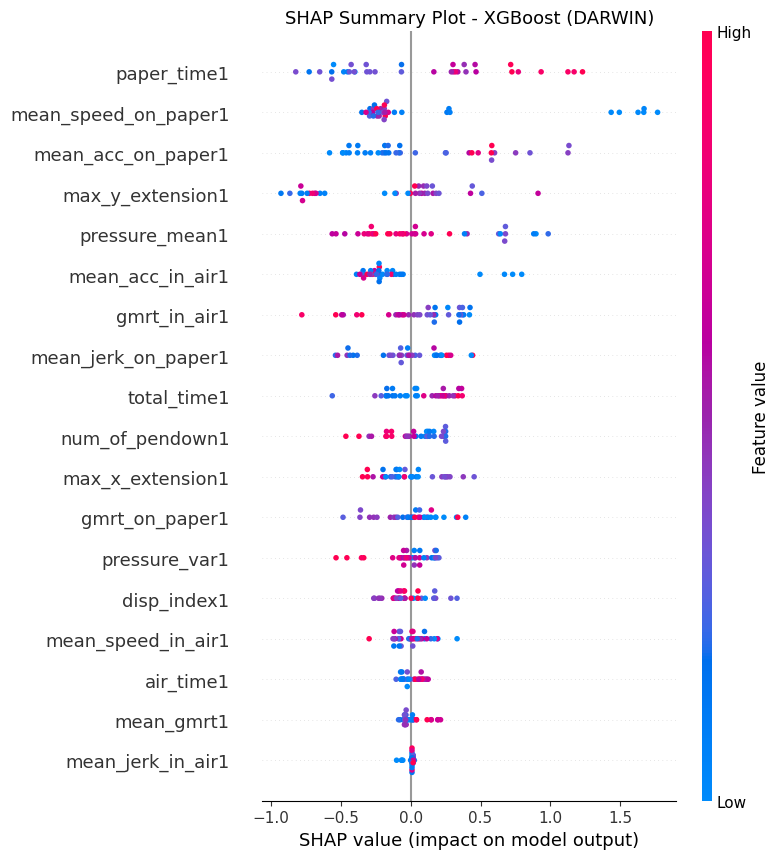

✔ Summary plot guardado.


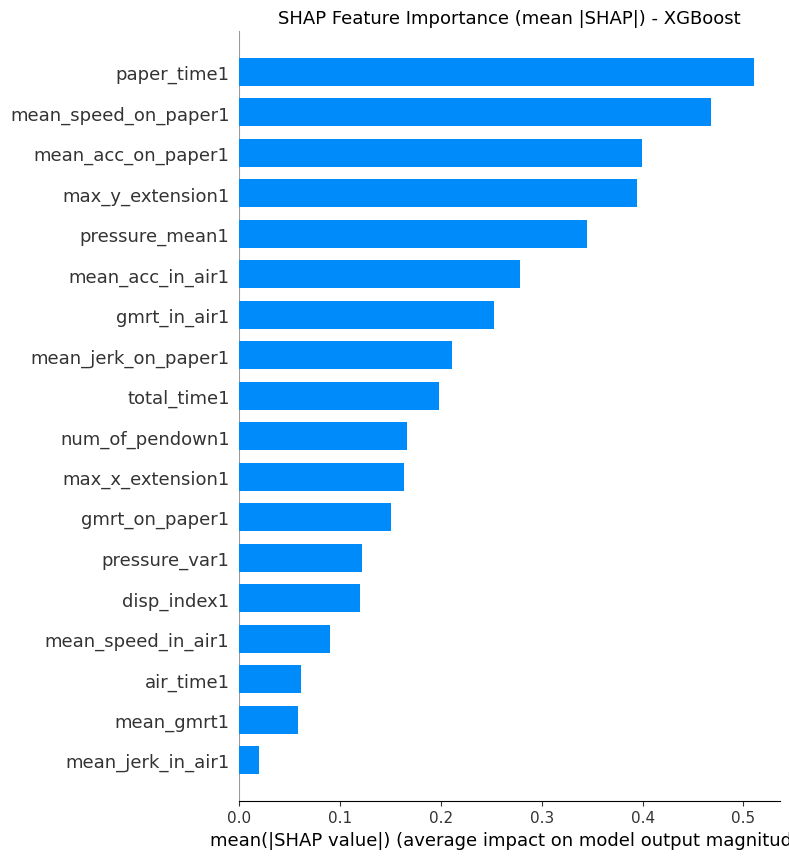

✔ Bar plot guardado.


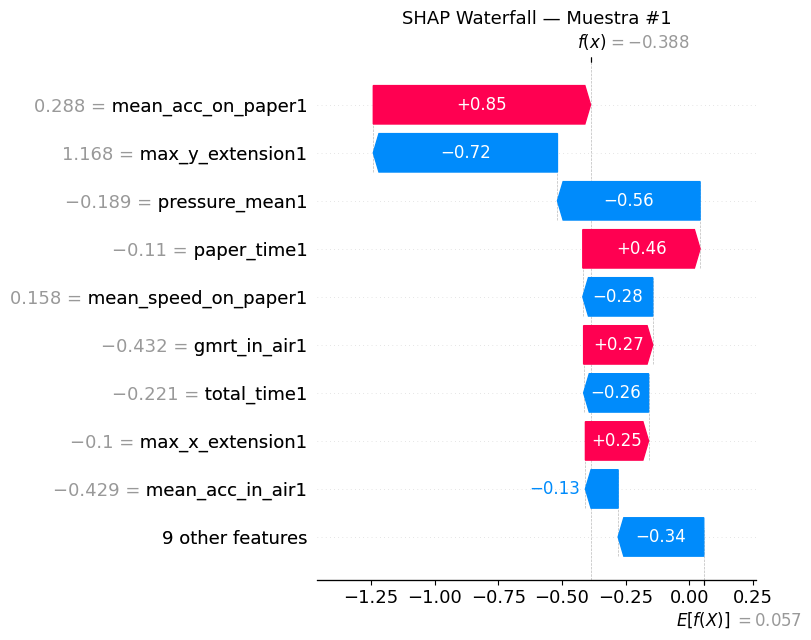

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

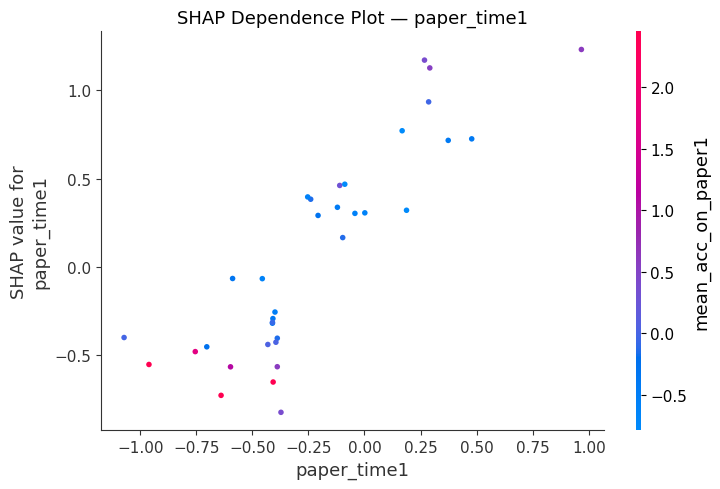

✔ Dependence plot guardado para: paper_time1

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===
             Feature  Mean |SHAP|
         paper_time1     0.510744
mean_speed_on_paper1     0.468034
  mean_acc_on_paper1     0.399294
    max_y_extension1     0.394698
      pressure_mean1     0.344589
    mean_acc_in_air1     0.278358
        gmrt_in_air1     0.253155
 mean_jerk_on_paper1     0.211381
         total_time1     0.198182
     num_of_pendown1     0.166239


In [113]:
# ============================================================
# ANÁLISIS SHAP PARA XGBOOST
# ============================================================

# Explainer SHAP (TreeExplainer es el óptimo para XGBoost)
explainer = shap.TreeExplainer(modelo_xgb) # 2

# Calcular los SHAP values sobre el test set
shap_values = explainer.shap_values(X_test_scaled)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# Muestra importancia + dirección del efecto de cada feature
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - XGBoost (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global (|SHAP|)
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# Desglosa la predicción de una sola muestra
# ============================================================
# Índice de la muestra a explicar (cámbialo si quieres otra)
sample_idx = 1

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx] if hasattr(X_test_scaled, '__array__') else X_test_scaled.iloc[sample_idx].values,
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# Relación entre el valor de la feature y su SHAP value
# ============================================================
# Identificar la feature con mayor impacto medio
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

plt.figure()
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features por |SHAP| medio
# ============================================================
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===")
print(feature_importance_df.head(10).to_string(index=False))

**LIME**


--- LIME XGBoost: instancia 1 ---
Clase real     : 1
Clase predicha : 0
Probabilidades : H=0.596 | P=0.404

Top features (peso LIME):
  mean_acc_on_paper1 > 0.13                      +0.1540
  -0.22 < mean_speed_on_paper1 <= 0.24           -0.0967
  -0.48 < pressure_mean1 <= 0.24                 -0.0875
  max_y_extension1 > 0.43                        -0.0823
  -0.19 < max_x_extension1 <= 0.03               +0.0749
  pressure_var1 > 0.56                           -0.0732
  -0.22 < paper_time1 <= 0.06                    +0.0709
  -0.68 < gmrt_in_air1 <= -0.25                  +0.0700
  -0.37 < total_time1 <= -0.22                   -0.0500
  gmrt_on_paper1 > 0.25                          +0.0451
  mean_jerk_on_paper1 > 0.18                     +0.0254
  -0.50 < mean_acc_in_air1 <= -0.37              -0.0185
  -0.62 < mean_speed_in_air1 <= -0.21            -0.0157
  -0.12 < disp_index1 <= 0.46                    -0.0150
  -0.19 < num_of_pendown1 <= 0.47                -0.0110


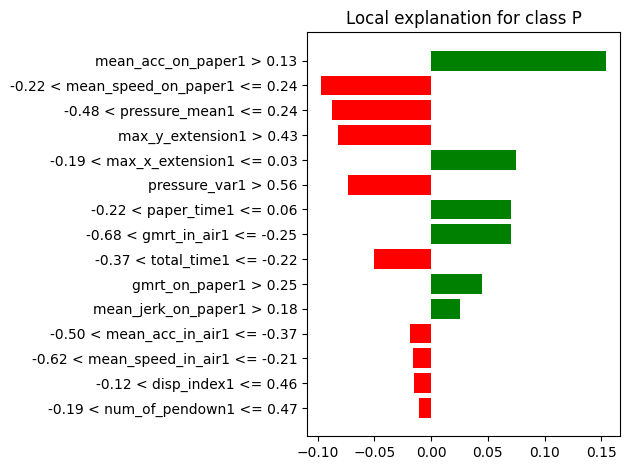


Calculando importancia global LIME (XGBoost)...

Top-20 features por importancia global LIME (XGBoost):
   1. mean_speed_on_paper1                      0.14188
   2. paper_time1                               0.13982
   3. mean_acc_on_paper1                        0.09223
   4. pressure_mean1                            0.09191
   5. gmrt_in_air1                              0.06919
   6. max_y_extension1                          0.06633
   7. mean_acc_in_air1                          0.05868
   8. pressure_var1                             0.04749
   9. num_of_pendown1                           0.04517
  10. gmrt_on_paper1                            0.04335
  11. max_x_extension1                          0.04179
  12. total_time1                               0.03875
  13. mean_jerk_on_paper1                       0.03376
  14. disp_index1                               0.03078
  15. mean_gmrt1                                0.02939
  16. air_time1                                 0.02514

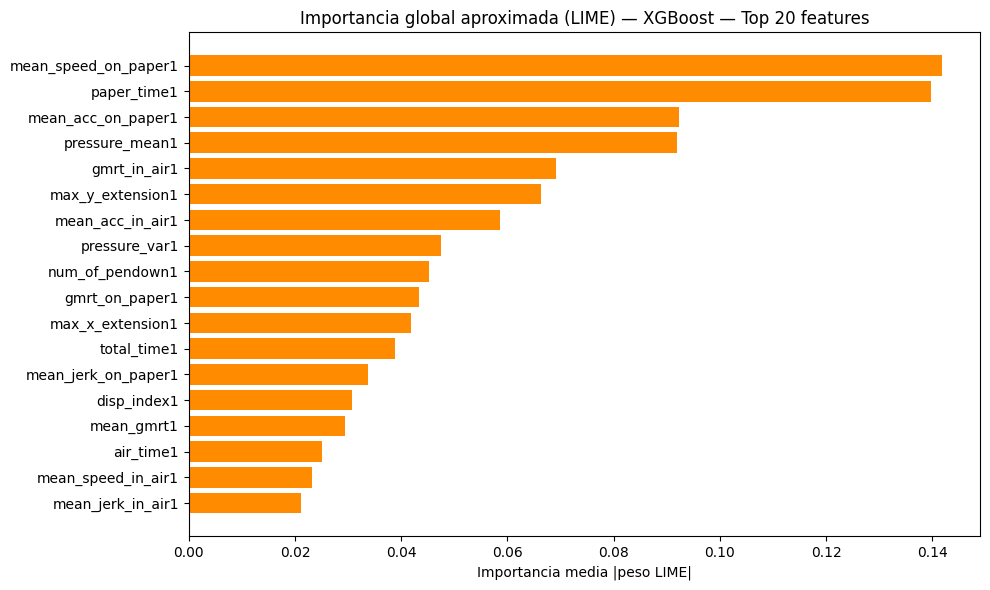

In [14]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO XGBoost
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = modelo_xgb.predict_proba, # modelo_xgb modelo_xgb2
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME XGBoost: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_xgb[INSTANCE_IDX]}") # Y_pred_xgb Y_pred_xgb2
print(f"Probabilidades : H={modelo_xgb.predict_proba([instance])[0][0]:.3f} | " # 2
      f"P={modelo_xgb.predict_proba([instance])[0][1]:.3f}") # 2
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (XGBoost)...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = modelo_xgb.predict_proba, # 2
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (XGBoost):")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="darkorange")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — XGBoost — Top 20 features")
plt.tight_layout()
plt.show()